# HHBANK - 2 COUNTRY GITHUB VERSION 

In [1]:
# PACKAGES AND PATHS 
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR_D = Path.cwd()

# REMOVE .parent here. cwc
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CALIBRATION
# ═══════════════════════════════════════════════════════════════════════
calibration_start = {

    # ── Preferences ──────────────────────────────────────────────────────
    #                              D               F
    'frisch_D':     1.0,    'frisch_F':     1.0,    # Frisch elasticity of labour supply
    'eis_D':        0.5,    'eis_F':        0.5,    # Elasticity of intertemporal substitution
    'habit_D':      0.00,   'habit_F':      0.00,   # Consumption habit strength
    'C_lag_D':      0.0,    'C_lag_F':      0.0,    # Lagged consumption weight

    # ── Rates & Asset Prices ─────────────────────────────────────────────
    # Task 1.1: rdep_F set = rdep_D = i_union.  Fisher (rdep_c = i_union - pi_c) with
    # pi_D = pi_F = 0 implies rdep_D = rdep_F = i_union in a monetary union at SS.
    # Country-specific patience is expressed through beta_c alone (solved endogenously).
    'rdep_D':       0.0065, 'rdep_F':       0.0065, # Real deposit rate (SS, pi=0; equal in MU)
    'rb_D':         0.0099, 'rb_F':         0.0075, # Bond rate (initial guess; solved endogenously)
    'Q_D':          1.0,    'Q_F':          1.0,    # Tobin's q

    # ── Production ───────────────────────────────────────────────────────
    'alpha_D':      0.35,   'alpha_F':      0.35,   # Capital share
    'delta_D':      0.0125, 'delta_F':      0.0125, # Quarterly depreciation rate
    'ksi_D':        0.5,    'ksi_F':        0.5,    # Capital adjustment cost curvature

    # ── Aggregate Targets (SS) ───────────────────────────────────────────
    'Y_D':          1.00,   'Y_F':          1.00,   # Output
    'N_D':          1.00,   'N_F':          1.00,   # Labour
    'w_D':          0.65,   'w_F':          0.65,   # Real wage
    'Y_ss_D':       1.0,    'Y_ss_F':       1.0,    # SS output anchor (Taylor rule)

    # ── Financial Intermediaries (Gertler-Karadi) ─────────────────────────
    'f_D':          0.97,   'f_F':          0.97,   # Exit probability
    # lambda_gk is solved endogenously by the SS solver (Task 1.3 Option B):
    # the IC theta = eta/(lambda_gk - nu) is enforced as an SS target.
    # The values below are initial guesses only.
    'lambda_gk_D':  0.2,    'lambda_gk_F':  0.2,   # Divertability fraction (IC constraint)
    'n_inter_D':    0.75*4, 'n_inter_F':    0.75*4, # Bank net worth
    'theta_D':      4,      'theta_F':      4,      # Initial leverage ratio

    # ── Fiscal & Government Debt ─────────────────────────────────────────
    'B_supply_D':   0.6*4,  'B_supply_F':   0.6*4,  # Total bond supply (≈ 60% of annual GDP)
    'b_gov_D':      0.6*4,  'b_gov_F':      0.6*4,  # Government bonds outstanding
    'b_gov_ss_D':   0.6*4,  'b_gov_ss_F':   0.6*4,  # SS debt anchor

    # ── Fiscal Rule (transfers) ──────────────────────────────────────────
    'tau_D':        0.181,  'tau_F':        0.181,  # Tax rate
    'lamb_D':       0.85,   'lamb_F':       0.85,   # Transfer-to-output ratio
    'lamb_ss_D':    0.85,   'lamb_ss_F':    0.85,   # SS transfer anchor
    'phi_lamb_D':   0.4,   'phi_lamb_F':   0.4,   # Surplus response to debt gap (Bohn rule)

    # ── Sovereign Default ────────────────────────────────────────────────
    'shock_def_D':      0.000,  'shock_def_F':      0.0,    # Exogenous default shock
    'def_rate_D':       0.000,  'def_rate_F':       0.0,    # Default rate (SS = 0)
    'def_scale_D':      0.0,    'def_scale_F':      0.0,    # Endogenous default sensitivity
    'def_curvature_D':  0.5,    'def_curvature_F':  0.5,    # Power-function curvature
    'def_offset_D':     0.05,   'def_offset_F':     0.05,   # Linearisation offset
    'recovery_rate_D':  0.40,   'recovery_rate_F':  0.40,   # Recovery on defaulted debt
    'zeta_writeoff_D':  1.0,    'zeta_writeoff_F':  1.0,    # 1 = full write-off; 0 = coupon haircut

    # ── Macroprudential Policy (Sovereign Capital Charge) ─────────────────
    'vartheta_D':       0.05,   'vartheta_F':       0.05,   # Policy intensity (0 = off)
    'w_sov_D':          1.0,    'w_sov_F':          1.0,    # Sovereign risk weight (hint; computed by risk_weight block)
    # Task 6.3: alpha_w_c = 10 is a STYLISED choice intended to amplify the
    # macroprudential channel for visibility in IRFs.  A 1% default rate implies
    # a 10 pp risk-weight increase, which is high relative to the Basel
    # Standardised Approach (~2 pp for investment-grade sovereigns).  Reduce to
    # alpha_w_c = 2 for a more defensible calibration; keep at 10 for visibility.
    'alpha_w_D':       10.0,    'alpha_w_F':       10.0,    # Rating sensitivity to lagged default rate
    'shock_w_sov_D':    0.0,    'shock_w_sov_F':    0.0,    # Exogenous credit-rating shock
    'phi_sov_D_ss':     0.0,    'phi_sov_F_ss':     0.0,    # SS banking-sector exposure (overwritten post-solve)

    # ── Trade & Terms of Trade ───────────────────────────────────────────
    'omega':            0.85,   # Home bias in consumption
    'epsilon_trade':    1.5,    # Trade elasticity
    'p':                1.0,    # Terms of trade (SS = 1) 

    # ── Cross-Border Bond Portfolio ──────────────────────────────────────
    # Task 6.4: F-banks hold a larger share of D-debt (phi_bD_F_ss = 0.20) than
    # D-banks hold of F-debt (phi_bF_D_ss = 0.15).  Interpretation: F is the
    # "core", yield-chasing into peripheral D-debt.  Not derived from primitives.
    'phi_bF_D_ss':  0.15,   'phi_bD_F_ss':  0.20,   # SS portfolio shares (foreign bonds / net worth)
    'psi_bF_D':     0.05,   'psi_bD_F':     0.05,   # Portfolio adjustment cost

    # ── Monetary Union (single CB) ───────────────────────────────────────
    'omega_union_U': 0.5,                           # D weight in union aggregates
    'i_union':       0.0065,                        # Nominal policy rate (SS)
    'r_star_U':      0.0065,                        # Natural real rate
    'phi_pi_U':      1.5,                           # Taylor rule: inflation response
    'phi_y_U':       0.125,                         # Taylor rule: output gap response
    'rho_i_U':       0.8,                           # Interest rate smoothing
    # Task 7.3: renamed eps_m_D → eps_m_U (union-level instrument, not country-D).
    'eps_m_U':       0.0,                           # Monetary policy shock (union-level)

    # ── Nominal Rigidities ───────────────────────────────────────────────
    #                              D               F
    'mu_p_D':       1.0,    'mu_p_F':       1.0,    # Price markup (SS)
    'mu_w_D':       1.0,    'mu_w_F':       1.0,    # Wage markup (SS)
    'kappa_p_D':    0.30,   'kappa_p_F':    0.30,   # Rotemberg price-adjustment slope
    'kappa_w_D':    0.30,   'kappa_w_F':    0.30,   # Rotemberg wage-adjustment slope

    # ── SS Nominal Variables ─────────────────────────────────────────────
    'pi_D':     0.0,    'pi_F':     0.0,            # Price inflation
    'pi_w_D':   0.0,    'pi_w_F':   0.0,            # Wage inflation
    'i_D':      0.0065, 'i_F':      0.0065,         # Nominal interest rate
    'mc_D':     1.0,    'mc_F':     1.0,            # Marginal cost
    'r_star_F': 0.0065,                             # F natural real rate (= r_star_U in MU)
    'phi_pi_F': 1.5,    'phi_y_F':  0.125,          # (unused; union CB overrides)
    'rho_i_F':  0.8,    'eps_m_F':  0.0,

    # ── Idiosyncratic Income Process (Rouwenhorst grid) ──────────────────
    'rho_z_D':  0.9,    'rho_z_F':  0.97,           # AR(1) persistence
    'sigma_z_D': 0.5,   'sigma_z_F': 0.8,           # Innovation std dev
    'nZ_D':     19,     'nZ_F':     21,             # Income grid points
    'nDep_D':   500,    'nDep_F':   500,            # Deposit grid points
    'Depmax_D': 150,    'Depmax_F': 150,            # Max deposit (borrowing limit)
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

# Task 7.4: div initial guesses set to rn_c * n_inter_c (≈ SS value) to
# speed up convergence.  After SS solve, assert div_D == rn_D * n_inter_D.
calibration_hh_D = {**calibration_start_D, 'beta_D': 0.9920094934, 'div_D': 0.19}
calibration_hh_F = {**calibration_start_F, 'beta_F': 0.9870643761, 'div_F': 0.21}


In [3]:
# ── Bond Holdings (initial SS guess; portfolio anchors overwritten post-solve) ──
_n_D, _n_F = calibration_start['n_inter_D'], calibration_start['n_inter_F']
_B_D, _B_F = calibration_start['B_supply_D'], calibration_start['B_supply_F']

b_F_D = calibration_start['phi_bF_D_ss'] * _n_D
b_D_F = calibration_start['phi_bD_F_ss'] * _n_F

calibration_start.update({
    'b_F_D': b_F_D,        'b_D_F': b_D_F,
    'b_D_D': _B_D - b_D_F, 'b_F_F': _B_F - b_F_D,
    'psi_bD_D': 0.05,       'psi_bF_F': 0.05,
})


In [4]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)

from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [ ]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, sdf_ss_D, government_ss_D, labor_ss_D,
    government_default_D, interest_rates_D, bond_return_D,
    ces_price_D, import_demand_D,
    ic_residual_D,          # Task 1.3: SS IC consistency for lambda_gk_D
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, sdf_ss_F, government_ss_F, labor_ss_F,
    government_default_F, interest_rates_F, bond_return_F,
    ces_price_F, import_demand_F,
    ic_residual_F,          # Task 1.3: SS IC consistency for lambda_gk_F
)

from equations_global import (
    trade_balance, global_bond_market, portfolio_adj_cost,
    domestic_bond_clearing, global_goods_mkt, terms_of_trade,
    risk_weight, macroprudential_wedge,
)


### SOLVING MODEL

#### STEADY STATE

In [ ]:
import copy

ha = sj.create_model([
    sdf_ss_D, government_default_D, interest_rates_D, bond_return_D,
    sdf_ss_F, government_default_F, interest_rates_F, bond_return_F,
    hh_extended_D, smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, government_ss_D, labor_ss_D,
    ic_residual_D,   # Task 1.3: pins lambda_gk_D so IC holds at theta_D=4
    hh_extended_F, smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, government_ss_F, labor_ss_F,
    ic_residual_F,   # Task 1.3: pins lambda_gk_F so IC holds at theta_F=4
    ces_price_D, import_demand_D, ces_price_F, import_demand_F,
    trade_balance, global_bond_market, global_goods_mkt,
    risk_weight, macroprudential_wedge,
], name='MU HA Model 2 Country')

# Task 1.3 (Option B): lambda_gk_D/F added as unknowns so the GK IC
#   theta = eta / (lambda_gk - nu) is satisfied exactly at SS.
# Task 1.1: rdep_F = rdep_D = i_union ensures Fisher residuals are zero.
unknowns_ss = {
    'beta_D':      0.9920094934,
    'beta_F':      0.9870643761,
    'p':           1.000,
    'lambda_gk_D': 0.202,        # initial guess slightly above 0.2
    'lambda_gk_F': 0.202,
}
targets_ss = ['deposit_mkt_D', 'deposit_mkt_F', 'goods_mkt_D', 'ic_res_D', 'ic_res_F']

ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss, solver='broyden_custom')

# ── Post-solve patches ────────────────────────────────────────────────────────
n_tot = float(ss['n_inter_D']) + float(ss['n_inter_F'])

anchors = {
    'phi_bF_D_ss':           float(calibration_start['b_F_D']) / float(calibration_start['n_inter_D']),
    'phi_bD_F_ss':           float(calibration_start['b_D_F']) / float(calibration_start['n_inter_F']),
    'phi_bD_D_ss':           float(ss['b_D_D']) / float(ss['n_inter_D']),
    'phi_bF_F_ss':           float(ss['b_F_F']) / float(ss['n_inter_F']),
    'excess_return_bD_D_ss': float(ss['rb_actual_D']) - float(ss['rdep_D']),
    'excess_return_bF_F_ss': float(ss['rb_actual_F']) - float(ss['rdep_F']),
    'excess_return_F_D_ss':  float(ss['rb_actual_F']) - float(ss['rdep_D']),
    'excess_return_D_F_ss':  float(ss['rb_actual_D']) - float(ss['rdep_F']),
    'phi_sov_D_ss':          (float(ss['b_D_D']) + float(ss['b_D_F'])) / n_tot,
    'phi_sov_F_ss':          (float(ss['b_F_F']) + float(ss['b_F_D'])) / n_tot,
    'p':                     float(ss['p']),
}
calibration_start.update(anchors)
# Also propagate solved lambda_gk back into calibration_start so ha_full picks them up
calibration_start['lambda_gk_D'] = float(ss['lambda_gk_D'])
calibration_start['lambda_gk_F'] = float(ss['lambda_gk_F'])

for k, v in anchors.items():
    ss.toplevel[k] = v

# SS seeds for ha_full blocks absent from ha
for k, v in {
    'phi_sov_D':      anchors['phi_sov_D_ss'], 'phi_sov_F':      anchors['phi_sov_F_ss'],
    'mp_wedge_D':     0.0,  'mp_wedge_F':     0.0,
    'firm_profit_D':  0.0,  'firm_profit_F':  0.0,
    'b_F_D_res':      0.0,  'b_D_F_res':      0.0,
    'rb_D_res':       0.0,  'rb_F_res':       0.0,
    'taylor_res_union': 0.0,
    'nkpc_p_res_D':   0.0,  'nkpc_p_res_F':   0.0,
    'nkpc_w_res_D':   0.0,  'nkpc_w_res_F':   0.0,
    'w_res_D':        0.0,  'w_res_F':        0.0,
    'p_res':          0.0,
    'rdep_ante_D': float(ss['rdep_D']), 'rdep_ante_F': float(ss['rdep_F']),
}.items():
    ss.toplevel[k] = v

cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)

print(f"beta_D={ss['beta_D']:.10f}  beta_F={ss['beta_F']:.10f}  p={ss['p']:.6f}")
print(f"lambda_gk_D={ss['lambda_gk_D']:.6f}  lambda_gk_F={ss['lambda_gk_F']:.6f}")
print(f"rb_D={ss['rb_D']:.6f}  rb_F={ss['rb_F']:.6f}  rdep_D={ss['rdep_D']:.6f}  rdep_F={ss['rdep_F']:.6f}")
print(f"phi_sov_D_ss={anchors['phi_sov_D_ss']:.6f}")

# Task 1.1 Fisher verification
assert abs(float(ss['rdep_D']) - float(ss['rdep_F'])) < 1e-8, "Fisher: rdep_D ≠ rdep_F"
assert abs(float(ss['rdep_D']) - float(ss['i_union'])) < 1e-8, "Fisher: rdep_D ≠ i_union"
# Task 1.3 IC verification
assert abs(float(ss['ic_res_D'])) < 1e-8, f"IC residual D = {ss['ic_res_D']:.2e}"
assert abs(float(ss['ic_res_F'])) < 1e-8, f"IC residual F = {ss['ic_res_F']:.2e}"
# Task 7.4 div consistency
assert abs(float(ss['div_D']) - float(ss['rn_D']) * float(ss['n_inter_D'])) < 1e-8, "div_D ≠ rn_D·n_inter_D"
print("All SS assertions passed.")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# TASK 1.2 — SS Block Residual Diagnostics
# Evaluates every ha_full block that is NOT enforced by the SS solver `ha`.
# All residuals should be < 1e-8 after Phases 1–3 are complete.
# ═══════════════════════════════════════════════════════════════════════
import numpy as np

def _get(k):
    return float(ss[k])

diag = {}

# ── Fisher ────────────────────────────────────────────────────────────
diag['fisher_D: rdep_D − (i_union − pi_D)'] = _get('rdep_D') - (_get('i_union') - _get('pi_D'))
diag['fisher_F: rdep_F − (i_union − pi_F)'] = _get('rdep_F') - (_get('i_union') - _get('pi_F'))

# ── GK Incentive Constraints ──────────────────────────────────────────
diag['IC_D: theta_D − eta_D/(lambda_gk_D − nu_D)'] = (
    _get('theta_D') - _get('eta_D') / (_get('lambda_gk_D') - _get('nu_D'))
)
diag['IC_F: theta_F − eta_F/(lambda_gk_F − nu_F)'] = (
    _get('theta_F') - _get('eta_F') / (_get('lambda_gk_F') - _get('nu_F'))
)

# ── intermediation_P1 (nu, eta Euler equations at SS, SDF = beta) ─────
for c in ['D', 'F']:
    f_c    = _get(f'f_{c}')
    lam    = _get(f'lambda_gk_{c}')
    th     = _get(f'theta_{c}')
    beta_c = _get(f'beta_{c}')
    rk_c   = _get(f'rk_{c}')
    rdep_c = _get(f'rdep_{c}')
    nu_c   = _get(f'nu_{c}')
    eta_c  = _get(f'eta_{c}')
    Omega_p1 = f_c + (1 - f_c) * lam * th   # SDF * Omega(+1) at SS
    diag[f'P1_{c}: nu_res']  = nu_c  - beta_c * Omega_p1 * (rk_c - rdep_c)
    diag[f'P1_{c}: eta_res'] = eta_c - beta_c * Omega_p1 * (1 + rdep_c)

# ── Pricing NKPC (pi = 0 at SS) ──────────────────────────────────────
for c in ['D', 'F']:
    pi_c  = _get(f'pi_{c}')
    mc_c  = _get(f'mc_{c}')
    kp    = _get(f'kappa_p_{c}')
    mu_p  = _get(f'mu_p_{c}')
    beta_c = _get(f'beta_{c}')
    # nkpc: pi - kappa*(mc - 1/mu) - beta*pi(+1) = 0  →  at SS: 0 - kappa*(mc-1/mu) = 0
    diag[f'NKPC_p_{c}'] = pi_c - kp * (mc_c - 1 / mu_p) - beta_c * pi_c

# ── Wage NKPC (pi_w = 0 at SS) ───────────────────────────────────────
for c in ['D', 'F']:
    pi_w_c = _get(f'pi_w_{c}')
    w_c    = _get(f'w_{c}')
    N_c    = _get(f'N_{c}')
    UCE_c  = _get(f'UCE_{c}')
    vphi_c = _get(f'vphi_{c}')
    fr_c   = _get(f'frisch_{c}')
    kw_c   = _get(f'kappa_w_{c}')
    mu_w_c = _get(f'mu_w_{c}')
    beta_c = _get(f'beta_{c}')
    diag[f'NKPC_w_{c}'] = (pi_w_c
                            - kw_c * (vphi_c * N_c**(1 + 1/fr_c) - (1/mu_w_c) * w_c * N_c * UCE_c)
                            - beta_c * pi_w_c)
    diag[f'w_res_{c}']  = w_c - w_c * (1 + pi_w_c) / (1 + _get(f'pi_{c}'))

# ── Taylor rule ───────────────────────────────────────────────────────
i_u   = _get('i_union')
pi_D_ = _get('pi_D'); pi_F_ = _get('pi_F')
Y_D_  = _get('Y_D');  Y_F_  = _get('Y_F')
Y_ss_D_ = _get('Y_ss_D'); Y_ss_F_ = _get('Y_ss_F')
omega_u = _get('omega_union_U')
rho_i   = _get('rho_i_U')
phi_pi  = _get('phi_pi_U')
phi_y   = _get('phi_y_U')
r_star  = _get('r_star_U')
pi_u    = omega_u * pi_D_ + (1 - omega_u) * pi_F_
Y_u     = omega_u * Y_D_  + (1 - omega_u) * Y_F_
Y_ss_u  = omega_u * Y_ss_D_ + (1 - omega_u) * Y_ss_F_
diag['taylor_rule_union'] = (i_u - rho_i * i_u
                              - (1 - rho_i) * (r_star + phi_pi * pi_u + phi_y * (Y_u / Y_ss_u - 1)))

# ── Domestic bond FOCs (portfolio_adj_cost and domestic_bond_foc_*) ───
for c, cross in [('D', 'F'), ('F', 'D')]:
    rb_actual_cross = _get(f'rb_actual_{cross}')
    rdep_c          = _get(f'rdep_{c}')
    phi_cross       = _get(f'b_{cross}_{c}') / _get(f'n_inter_{c}')
    phi_cross_ss    = _get(f'phi_b{cross}_{c}_ss')
    psi_cross       = _get(f'psi_b{cross}_{c}')
    er_cross        = _get(f'excess_return_{cross}_{c}_ss')
    diag[f'portfolio_adj_b{cross}_{c}'] = (
        (rb_actual_cross - rdep_c) - er_cross - psi_cross * (phi_cross - phi_cross_ss)
    )
    rb_actual_c = _get(f'rb_actual_{c}')
    phi_dom     = _get(f'b_{c}_{c}') / _get(f'n_inter_{c}')
    phi_dom_ss  = _get(f'phi_b{c}_{c}_ss')
    psi_dom     = _get(f'psi_b{c}_{c}')
    er_dom      = _get(f'excess_return_b{c}_{c}_ss')
    diag[f'dom_bond_foc_{c}'] = (
        (rb_actual_c - rdep_c) - er_dom - psi_dom * (phi_dom - phi_dom_ss)
    )

# ── Walras: global goods market ───────────────────────────────────────
diag['global_goods_res'] = _get('global_goods_res')

# ── Terms of trade (p_res = p - p*1/1 = 0 at SS) ─────────────────────
diag['terms_of_trade_p_res'] = _get('p') - _get('p') * (1 + _get('pi_F')) / (1 + _get('pi_D'))

# ── Print results ─────────────────────────────────────────────────────
print(f"\n{'Block residual':<50} {'Value':>14}  {'|res| > 1e-6?':>14}")
print("-" * 82)
FLAGGED = []
for name, val in diag.items():
    flagged = abs(val) > 1e-6
    if flagged:
        FLAGGED.append(name)
    marker = " *** FAIL" if flagged else ""
    print(f"  {name:<48} {val:>14.6e}{marker}")
print("-" * 82)
if FLAGGED:
    print(f"\nFLAGGED ({len(FLAGGED)} residuals > 1e-6):")
    for f in FLAGGED:
        print(f"  • {f}")
else:
    print("\nAll residuals < 1e-6  ✓")


In [7]:
# ── Print all steady-state scalar variables and their values ──────────────────
import pandas as pd
import numpy as np

ss_dict = {}
for k, v in ss.toplevel.items():
    try:
        arr = np.asarray(v)
        if arr.ndim == 0:          # true scalar
            ss_dict[k] = float(arr)
        elif arr.size == 1:        # single-element array
            ss_dict[k] = float(arr.flat[0])
        # skip arrays with more than 1 element (e.g. distribution grids)
    except Exception:
        pass

ss_df = (pd.DataFrame(ss_dict.items(), columns=['Variable', 'SS Value'])
           .sort_values('Variable')
           .reset_index(drop=True))

pd.set_option('display.max_rows', 300)
pd.set_option('display.float_format', '{:.8f}'.format)
print(ss_df.to_string(index=False))


             Variable     SS Value
                  A_D   1.00171972
                  A_F   0.99826985
           B_supply_D   2.40000000
           B_supply_F   2.40000000
                  C_D   0.77151820
                  C_F   0.78420894
              C_lag_D   0.00000000
              C_lag_F   0.00000000
                DEP_D   9.00000000
                DEP_F   9.00000000
           D_supply_D   9.00000000
           D_supply_F   9.00000000
             Depmax_D 150.00000000
             Depmax_F 150.00000000
                  G_D   0.10832652
                  G_F   0.09593591
                 IM_D   0.15125539
                 IM_F   0.14875266
                  I_D   0.12187500
                  I_F   0.11812500
                  K_D   9.75000000
                  K_F   9.45000000
                 NX_D  -0.00171972
                 NX_F   0.00172867
                  N_D   1.00000000
                  N_F   1.00000000
              Omega_D   0.75840617
              Omega_

#### OFF STEADY-STATE EQUATIONS

In [8]:
from equations_D import (
    capital_adj_D, labor_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D,     # GK IC: Q*K = theta*n_inter
    intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    firm_profit_D,
    domestic_bond_foc_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D,
    bond_return_D, sdf_D,
    fisher_D, taylor_rule_union, pricing_D, wage_setting_D,
)

from equations_F import (
    capital_adj_F, labor_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F,     # GK IC: Q*K = theta*n_inter
    intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    firm_profit_F,
    domestic_bond_foc_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F,
    bond_return_F, sdf_F,
    fisher_F, pricing_F, wage_setting_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_adj_cost,
    global_goods_mkt, terms_of_trade,
    risk_weight, macroprudential_wedge,
)


#### FULL MODEL

In [ ]:
import sys
sys.setrecursionlimit(5000)   # SSJ topological sort uses recursion on deep block graphs

financial_solved_D = combine([
    intermediation_IC_D, intermediation_P1_D,
]).solved(
    unknowns={'nu_D': float(cali_D['nu_D']), 'eta_D': float(cali_D['eta_D'])},
    targets=['nu_res_D', 'eta_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    intermediation_IC_F, intermediation_P1_F,
]).solved(
    unknowns={'nu_F': float(cali_F['nu_F']), 'eta_F': float(cali_F['eta_F'])},
    targets=['nu_res_F', 'eta_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    # ── Country D ──────────────────────────────────────────────────────────────
    hh_extended_D,
    sdf_D,
    government_default_D,       # → def_rate_D
    financial_solved_D,         # → theta_D = eta_D / (lambda_gk_D - nu_D)
    bond_return_D,
    bank_return_D,              # Task 2.1: uses PROMISED rb_D(-1) AND rb_F(-1); no quad cost (Task 2.2)
    intermediation_P2_D,        # Task 2.1: writedown_D + writedown_F bypass (1-f) filter
    intermediation_P3_D,
    k_balance_sheet_D,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_D,
    tax_rule_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    firm_profit_D,
    pricing_D,
    wage_setting_D,
    fisher_D,
    banker_div_res_D,
    market_clearing_D,

    # ── Country F ──────────────────────────────────────────────────────────────
    hh_extended_F,
    sdf_F,
    government_default_F,       # → def_rate_F
    financial_solved_F,         # → theta_F = eta_F / (lambda_gk_F - nu_F)
    bond_return_F,
    bank_return_F,              # Task 2.1: uses PROMISED rb_F(-1) AND rb_D(-1); no quad cost (Task 2.2)
    intermediation_P2_F,        # Task 2.1: writedown_F + writedown_D bypass (1-f) filter
    intermediation_P3_F,
    k_balance_sheet_F,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_F,
    tax_rule_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    firm_profit_F,
    pricing_F,
    wage_setting_F,
    fisher_F,
    banker_div_res_F,
    market_clearing_F,

    # ── Global ─────────────────────────────────────────────────────────────────
    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    domestic_bond_clearing,
    portfolio_adj_cost,
    risk_weight,                # → w_sov_c = 1 + alpha_w_c·def_rate_c(t) + shock_w_sov_c
    macroprudential_wedge,      # → mp_wedge_D, mp_wedge_F
    domestic_bond_foc_D,
    domestic_bond_foc_F,
    # Task 3.1: terms_of_trade pins p via the law of motion p = p(-1)·(1+pi_F)/(1+pi_D).
    # Under sticky nominal prices, the ToT is determined by inflation differentials,
    # not freely by goods-market clearing.  goods_mkt_D is therefore DROPPED from
    # targets (Walras: with bond markets and one goods market cleared by terms_of_trade,
    # the other clears automatically).  global_goods_res monitors Walras satisfaction.
    terms_of_trade,             # → p_res (Task 3.1)
    global_goods_mkt,
    taylor_rule_union,
], name="Full 2-Country MU HANK-NK")

unknowns_tp = [
    'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'Y_D', 'b_F_D',
    'pi_D', 'pi_w_D', 'w_D',
    'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'Y_F', 'b_D_F',
    'pi_F', 'pi_w_F', 'w_F',
    'i_union', 'p', 'rb_D', 'rb_F',
]
targets_tp = [
    'deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D',
    'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res',
    'nkpc_p_res_D', 'nkpc_w_res_D', 'w_res_D',
    'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F',
    'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res',
    'nkpc_p_res_F', 'nkpc_w_res_F', 'w_res_F',
    'taylor_res_union',
    'p_res',          # Task 3.1: replaces goods_mkt_D (ToT determined by Fisher/inflation)
    'rb_D_res', 'rb_F_res',
]

T = 500
# Task 7.3: eps_m_D renamed to eps_m_U (union-level instrument)
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F', 'eps_m_U',
             'shock_w_sov_D', 'shock_w_sov_F']

print(f"Unknowns ({len(unknowns_tp)}): {unknowns_tp}")
print(f"Targets  ({len(targets_tp)}): {targets_tp}")
print(f"\nComputing Jacobian for horizon T={T}...")
G_jac = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)
print("Jacobian computed successfully.")


### IMPULSE RESPONSE FUNCTIONS

In [20]:
BLUE    = '#002147'
RED   = '#8C1515'
BLUE_MUTED     = '#4a6f8a'  
RED_MUTED      = '#c0624a'

_COLORS     = [BLUE, RED, BLUE_MUTED, RED_MUTED]
_LINESTYLES = ['-', '--', '-.', ':']
_MARKERS    = ['', '', '', 'o']

def show_irfs(irfs_list, variables, labels=None,
              ylabel='Deviation from SS (pp)', T_plot=50, figsize=(18, 5)):

    labels = labels or [''] * len(irfs_list)
    n_var  = len(variables)
    fig, axes = plt.subplots(1, n_var, figsize=figsize, sharey=False)
    if n_var == 1:
        axes = [axes]

    for i, (ax, var) in enumerate(zip(axes, variables)):
        for j, (irf, label) in enumerate(zip(irfs_list, labels)):
            data = irf[var][:T_plot] if var in irf else np.zeros(T_plot)
            mkr  = _MARKERS[j % len(_MARKERS)]
            ax.plot(data,
                    color     = _COLORS[j % len(_COLORS)],
                    linestyle = _LINESTYLES[j % len(_LINESTYLES)],
                    linewidth = 1.8,
                    marker    = mkr,
                    markersize= 4,
                    markevery = 4,
                    label     = label)

        ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':')
        ax.set_title(var, fontsize=10, pad=6)
        ax.set_xlabel('Quarter', fontsize=9)
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
        if any(l for l in labels):
            ax.legend(fontsize=8, frameon=False)

    fig.tight_layout()
    plt.show()


In [11]:
# ── Impulse Response Functions ────────────────────────────────────────────────  

# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

print("Computing IRF: TFP shock...")
irfs_Z_D = ha_full.solve_impulse_linear(
    ss_final, unknowns_tp, targets_tp, {'Z_D': dZ_D}
)

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)

print("Computing IRF: default shock...")
irfs_def_D = ha_full.solve_impulse_linear(
    ss_final, unknowns_tp, targets_tp, {'shock_def_D': dShock_def_D}
)

Computing IRF: TFP shock...
Computing IRF: default shock...


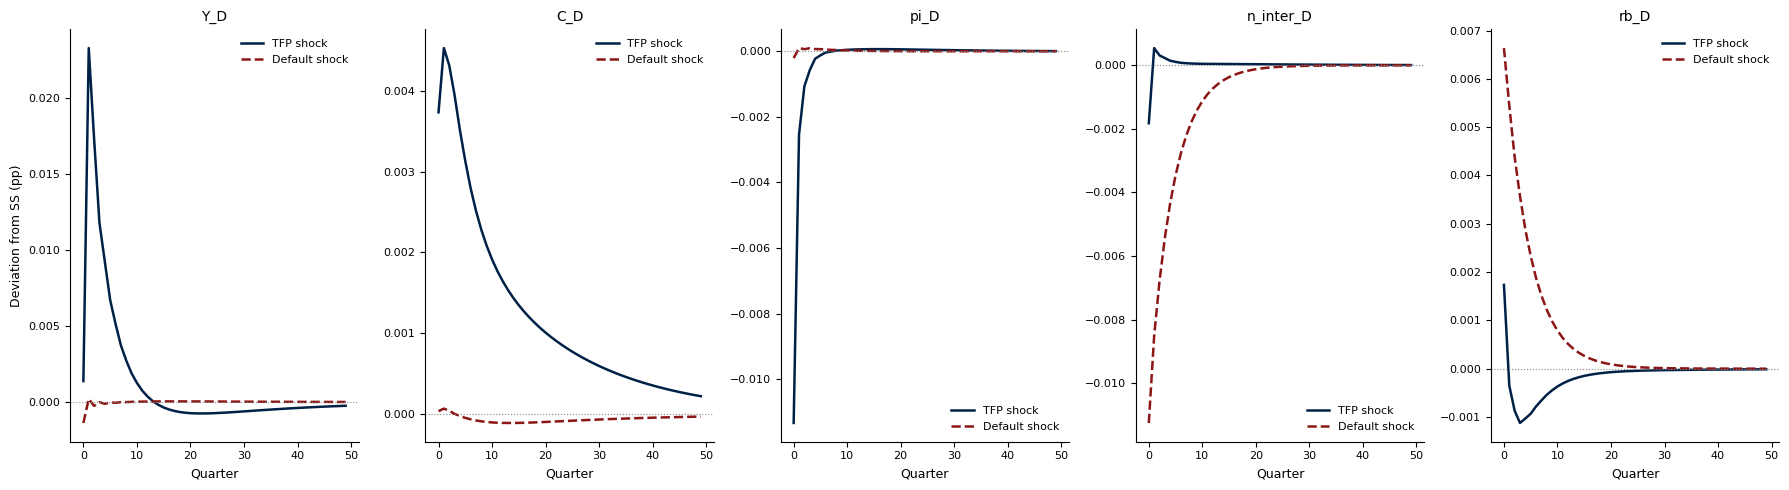

In [21]:
#TFP Shock
show_irfs([irfs_Z_D,   irfs_def_D],
          ['Y_D', 'C_D', 'pi_D', 'n_inter_D', 'rb_D'],
          ['TFP shock', 'Default shock'])

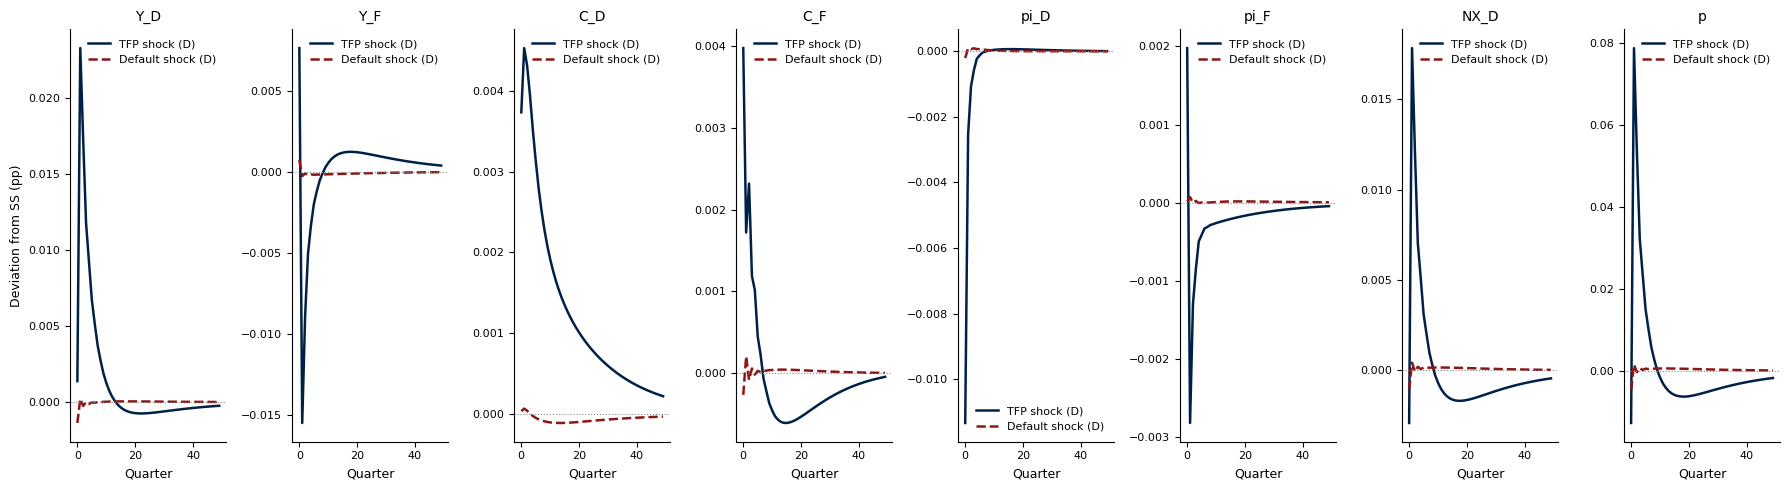

In [22]:
# ── 1. Output & Inflation ─────────────────────────────────────────────────
# Suggestion: include NX and p to capture current-account / terms-of-trade
# dynamics alongside the domestic demand decomposition.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['Y_D', 'Y_F', 'C_D', 'C_F', 'pi_D', 'pi_F', 'NX_D', 'p'])


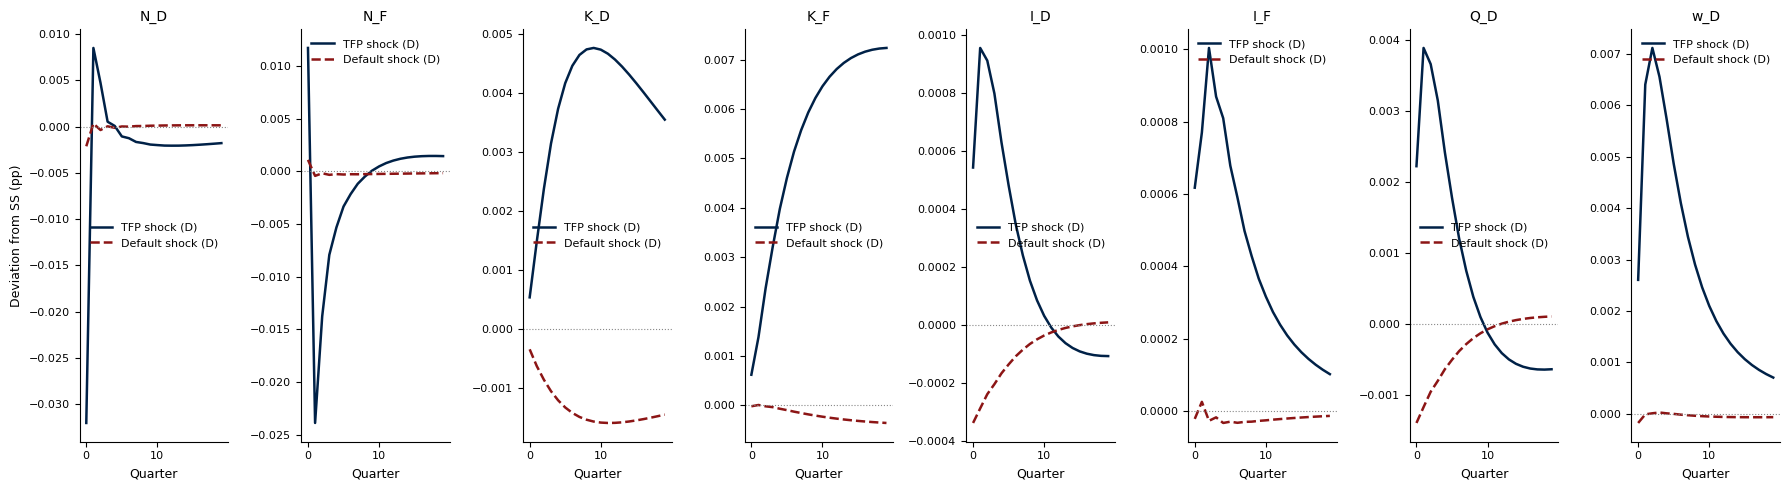

In [14]:
# ── 2. Labour, Capital & TFP ──────────────────────────────────────────────
# Suggestion: add Q (Tobin's q) and rk — these reveal whether output
# rigidity is coming from the investment or the labour margin.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['N_D', 'N_F', 'K_D', 'K_F', 'I_D', 'I_F', 'Q_D', 'w_D'])


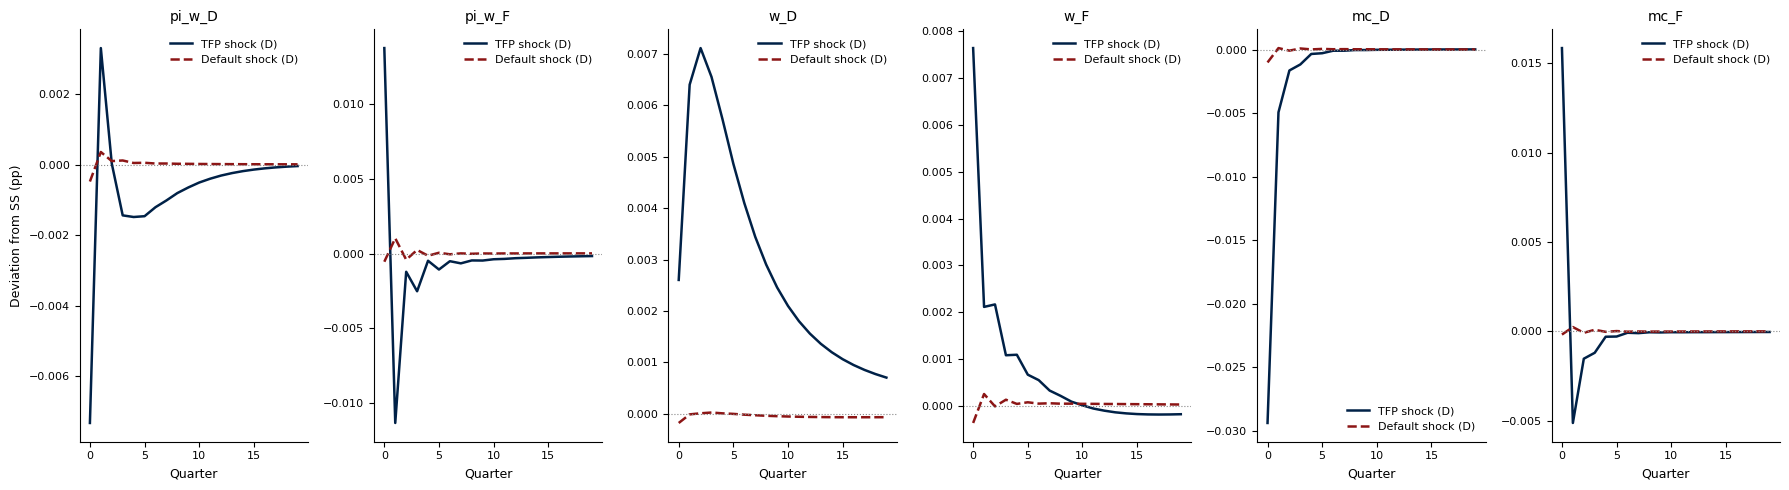

In [15]:
# ── 3. Wages & Price Rigidities ───────────────────────────────────────────
# Suggestion: plot pi_w alongside mc to see how much of the inflation
# response is cost-push vs. wage-push — useful for kappa sensitivity.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['pi_w_D', 'pi_w_F', 'w_D', 'w_F', 'mc_D', 'mc_F'])


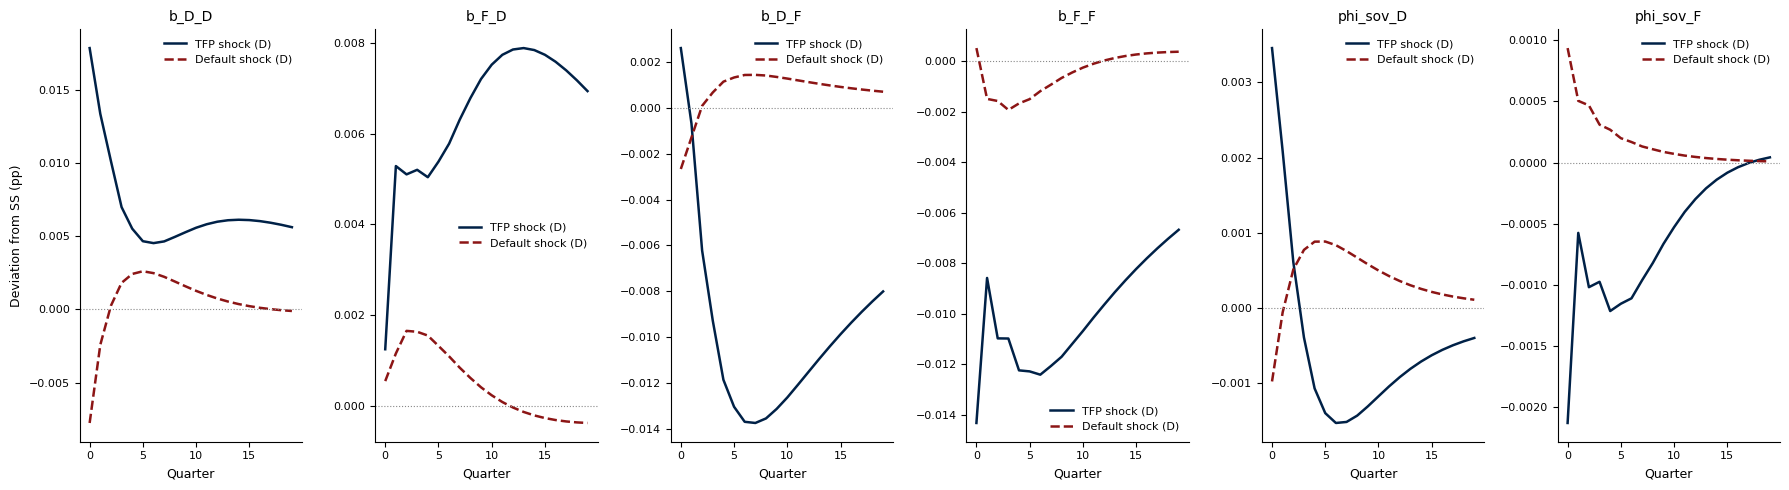

In [16]:
# ── 4. Bond Holdings ──────────────────────────────────────────────────────
# Suggestion: add phi_sov_D / phi_sov_F (risk-weighted exposure) alongside
# raw holdings to show when the macroprudential wedge bites.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_D_D', 'b_F_D', 'b_D_F', 'b_F_F', 'phi_sov_D', 'phi_sov_F'])


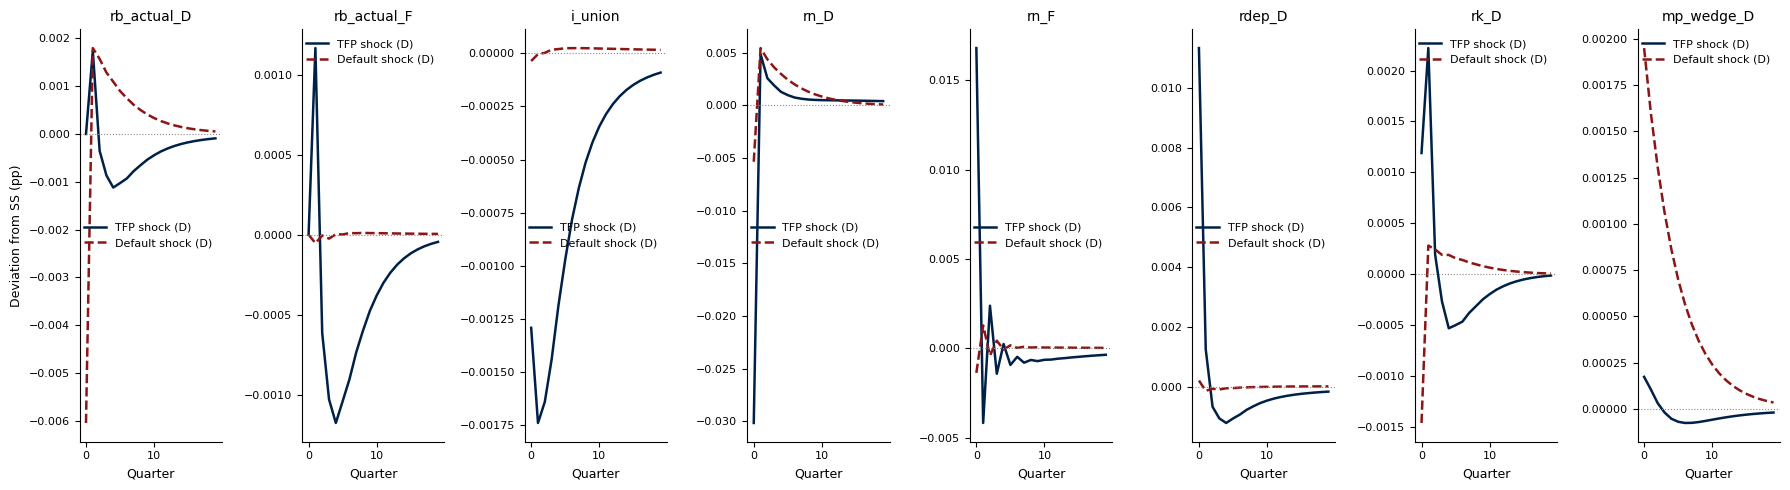

In [17]:
# ── 5. Rates & Returns ────────────────────────────────────────────────────
# Suggestion: include rk_D alongside rn_D to decompose bank return into
# capital-return and bond-return channels (GK mechanism).
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['rb_actual_D', 'rb_actual_F', 'i_union', 'rn_D', 'rn_F', 'rdep_D', 'rk_D', 'mp_wedge_D'])
 

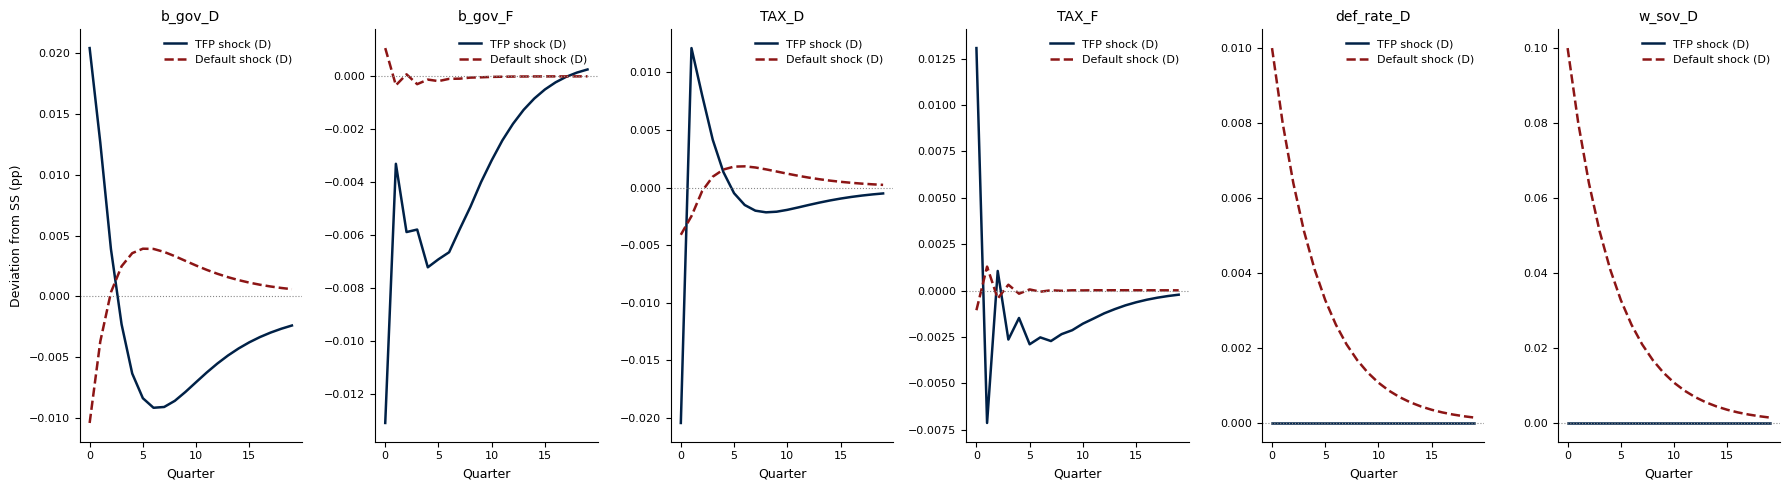

In [18]:
# ── 6. Fiscal ─────────────────────────────────────────────────────────────
# Suggestion: add def_rate and w_sov to trace the full sovereign-risk loop:
# debt → default rate → risk weight → mp_wedge → rb (back to debt).
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_gov_D', 'b_gov_F', 'TAX_D', 'TAX_F', 'def_rate_D', 'w_sov_D'])


In [ ]:
# ── 7. Market Clearing & Walras Residuals (Task 3.2 — should all be ≈ 0) ───
# goods_mkt_F and global_goods_res are NOT targets — they must be zero by Walras.
# Assertions enforce this automatically for every shock.

def _check_walras(irfs, shock_name, tol=1e-6):
    for var in ['global_goods_res', 'goods_mkt_F']:
        if var in irfs:
            max_res = float(np.abs(irfs[var][:T]).max())
            status = "PASS" if max_res < tol else f"FAIL  max={max_res:.2e}"
            print(f"  {shock_name:30s}  {var:20s}  {status}")
            assert max_res < tol, f"Walras violation: {var} max={max_res:.2e} for {shock_name}"

print("Walras checks (global_goods_res, goods_mkt_F should be < 1e-6):")
_check_walras(irfs_Z_D,   'TFP shock D')
_check_walras(irfs_def_D, 'Default shock D')
print("All Walras checks passed ✓\n")

show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# TASK 6.2 — Sensitivity Table: def_offset × def_scale
#
# Linearised slope at SS: d(def_rate_D)/d(gap) = def_scale · curvature · offset^(curvature−1)
# With curvature=0.5: slope = def_scale · 0.5 / sqrt(offset).
# Halving offset from 0.05 to 0.025 increases slope by √2 ≈ 41 %.
# SS is invariant because gap=0 at SS regardless of (offset, scale).
# ═══════════════════════════════════════════════════════════════════════
import itertools

offsets = [0.025, 0.05, 0.10]
scales  = [0.0, 0.025, 0.05, 0.10]

rho_def = 0.8
dShock = 0.01 * rho_def ** np.arange(T)

# Store peak impact of def_rate_D for a 1% debt-level shock
results = {}
for offset, scale in itertools.product(offsets, scales):
    # Perturb calibration; SS invariant since gap=0 → no re-solve needed
    cali_perturb = {**calibration_start,
                    'def_offset_D': offset,
                    'def_scale_D':  scale}
    # Update ss_final with perturbed params (only exogenous calibration, not solved)
    ss_perturb = copy.deepcopy(ss_final)
    ss_perturb.toplevel['def_offset_D'] = offset
    ss_perturb.toplevel['def_scale_D']  = scale
    try:
        irf = ha_full.solve_impulse_linear(
            ss_perturb, unknowns_tp, targets_tp, {'shock_def_D': dShock}
        )
        peak_def = float(np.abs(irf['def_rate_D'][:50]).max())
    except Exception as e:
        peak_def = float('nan')
    results[(offset, scale)] = peak_def

import pandas as pd
rows = []
for offset in offsets:
    row = {'def_offset': offset}
    for scale in scales:
        row[f'def_scale={scale}'] = results[(offset, scale)]
    rows.append(row)

sens_df = pd.DataFrame(rows).set_index('def_offset')
print("Peak |def_rate_D| IRF response to 1% shock_def_D, by (def_offset, def_scale):")
print(sens_df.to_string(float_format='{:.5f}'.format))

# Plot: peak def_rate_D vs offset for each scale
fig, ax = plt.subplots(figsize=(7, 4))
for scale in scales:
    peaks = [results[(o, scale)] for o in offsets]
    ax.plot(offsets, peaks, marker='o', label=f'def_scale={scale}')
ax.set_xlabel('def_offset')
ax.set_ylabel('Peak |def_rate_D|')
ax.set_title('Task 6.2 — Default sensitivity: peak IRF vs. offset/scale')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
